# Proyecto Final — Minería de Datos
## Relación entre Emisiones de CO2 y Cambio de Temperatura Global

**Fuente de datos:** Our World in Data — CO2 and Greenhouse Gas Emissions
(https://github.com/owid/co2-data)

**Problemática:** ¿Existe una relación medible entre las emisiones de CO2 de un país
(totales y per cápita) y el cambio de temperatura global que le es atribuible?

**Variable dependiente:** `temperature_change_from_co2`
**Variables independientes:** `co2`, `co2_per_capita`, `population`

---
## Sección 1: Carga y Exploración Inicial de los Datos


**Celda 1:** Carga del dataset descargado de Our World in Data y vista previa de las primeras filas.

In [1]:
import pandas as pd

df = pd.read_csv("../data/owid-co2-data.csv")
df.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Celda 2:** Dimensiones del dataset (filas, columnas) y lista de todas las columnas disponibles.

In [2]:
print(df.shape)
print(df.columns.tolist())

(50411, 79)
['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_capita', 'nitrous_oxide', 'nitrous_oxide_p

**Celda 3:** Tipos de dato y conteo de valores no nulos por columna - primer vistazo a dónde hay huecos en los datos.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  str    
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  str    
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc                

**Celda 4:** Estadísticas descriptivas (promedio, mínimo, máximo, percentiles) de todas las columnas numéricas.

In [4]:
df.describe()

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.000000,4.116700e+04,1.525100e+04,29173.000000,25648.000000,29384.000000,27216.000000,26239.000000,23796.000000,23496.000000,...,2170.000000,41238.000000,38280.000000,41238.000000,41238.000000,38280.000000,38150.000000,37813.000000,4712.000000,4712.000000
mean,1920.349249,6.017294e+07,3.300495e+11,7.890109,0.060026,420.227035,6.268847,42.598225,544.144592,7.483698,...,7.190616,2.272236,0.002871,0.008014,0.011224,0.000509,490.799608,310.521459,-6.986781,21.468641
std,65.859123,3.308412e+08,3.086383e+12,62.988171,0.123566,1972.092032,62.199548,1721.913018,2273.281696,99.512520,...,17.448980,9.282343,0.015362,0.045687,0.062888,0.003048,2414.076755,1812.363570,259.018184,62.637598
min,1750.000000,2.150000e+02,4.998000e+07,0.000000,0.000000,0.000000,-1928.339000,-100.000000,-84.560000,-2298.978000,...,0.000000,-0.824000,-0.001000,0.000000,-0.001000,0.000000,-19.725000,0.000000,-2177.807000,-98.281000
25%,1875.000000,3.272140e+05,7.874038e+09,0.000000,0.000000,0.381000,-0.005000,-1.070500,6.667750,-0.727500,...,0.144000,0.003000,0.000000,0.000000,0.000000,0.000000,1.502000,0.221000,-2.262250,-6.828750
50%,1925.000000,2.291264e+06,2.743861e+10,0.000000,0.001000,5.081000,0.044000,3.813000,28.120000,0.112000,...,0.588500,0.081000,0.000000,0.000000,0.000000,0.000000,14.605500,2.222000,1.641000,8.381500
75%,1975.000000,9.986553e+06,1.212627e+11,0.524000,0.077000,53.656500,1.018000,10.884000,124.303250,2.765250,...,2.416500,0.373000,0.000000,0.001000,0.002000,0.000000,76.508500,27.863000,11.425500,32.782250
max,2024.000000,8.161973e+09,1.301126e+14,1666.885000,2.484000,38598.578000,1804.657000,180870.000000,43184.086000,2614.874000,...,100.000000,100.000000,0.377000,1.216000,1.678000,0.085000,54433.398000,43714.777000,1768.846000,1023.042000


**Celda 5:** Cantidad de países distintos en el dataset y el rango de años disponible.

In [5]:
print(df['country'].nunique())
print(df['year'].min(), '-', df['year'].max())

254
1750 - 2024


---
## Sección 2: Preparación y Limpieza de los Datos


**Celda 6:** Selección de las columnas relevantes para nuestra problemática (país, año, CO2, CO2 per cápita, PIB, población y cambio de temperatura).

In [6]:
cols = ['country', 'year', 'co2', 'co2_per_capita', 'gdp', 'population',
        'temperature_change_from_co2', 'temperature_change_from_ghg']
df_sub = df[cols]
df_sub.head()

,country,year,co2,co2_per_capita,gdp,population,temperature_change_from_co2,temperature_change_from_ghg
0,Afghanistan,1750,NaN,NaN,NaN,2802560.0,NaN,NaN
1,Afghanistan,1751,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,NaN,NaN,NaN,NaN,NaN,NaN


**Celda 7:** Conteo de valores nulos en las columnas seleccionadas.

In [7]:
df_sub.isnull().sum()

country                            0
year                               0
co2                            21027
co2_per_capita                 23902
gdp                            35160
population                      9244
temperature_change_from_co2     9173
temperature_change_from_ghg     9173
dtype: int64

**Celda 8:** Eliminación de agregados regionales ("World", "Asia", grupos de ingreso, etc.) para quedarnos solo con países individuales reales.

In [8]:
regiones = ['World', 'Asia', 'Africa', 'Europe', 'North America', 'South America',
            'Oceania', 'European Union (27)', 'European Union (28)',
            'High-income countries', 'Low-income countries',
            'Lower-middle-income countries', 'Upper-middle-income countries']

df_sub = df_sub[~df_sub['country'].isin(regiones)]
print(df_sub.shape)

(46836, 8)


**Celda 9:** Filtrado del periodo a partir de 1950, año desde el cual la cobertura de datos es mucho más completa.

In [9]:
df_clean = df_sub[df_sub['year'] >= 1950]
print(df_clean.shape)
df_clean.isnull().sum()

(18009, 8)


country                           0
year                              0
co2                            1437
co2_per_capita                 2491
gdp                            6552
population                     1734
temperature_change_from_co2    1209
temperature_change_from_ghg    1209
dtype: int64

**Celda 10:** Eliminación de filas con valores nulos en las variables clave del análisis (se deja el PIB aparte intencionalmente, por tener muchos más datos faltantes).

In [10]:
df_clean = df_clean.dropna(subset=['co2', 'co2_per_capita', 'temperature_change_from_co2', 'population'])
print(df_clean.shape)
df_clean.isnull().sum()

(15218, 8)


country                           0
year                              0
co2                               0
co2_per_capita                    0
gdp                            3981
population                        0
temperature_change_from_co2       0
temperature_change_from_ghg       0
dtype: int64

**Celda 11:** Guardado del dataset ya limpio (`df_clean`) en un nuevo archivo CSV, para no repetir la limpieza cada vez.

In [11]:
df_clean.to_csv('../data/co2_clean.csv', index=False)
print("Guardado:", df_clean.shape)

Guardado: (15218, 8)


---
## Sección 3: Exploración Visual de los Datos Limpios


**Celda 12:** Top 10 países con mayores emisiones totales de CO2 en 2022, para tener una primera intuición de los datos.

In [12]:
top10 = df_clean[df_clean['year']==2022].sort_values('co2', ascending=False).head(10)
top10[['country','co2','co2_per_capita','temperature_change_from_co2']]

,country,co2,co2_per_capita,temperature_change_from_co2
9931,China,11711.808,8.218,0.144
48005,United States,5055.403,14.802,0.242
21760,India,2831.132,1.986,0.039
38312,Russia,1675.461,11.509,0.094
23810,Japan,1029.645,8.237,0.032
22660,Iran,767.178,8.570,0.010
21935,Indonesia,758.021,2.719,0.040
18317,Germany,667.843,7.942,0.043
40287,Saudi Arabia,666.994,20.730,0.008
43036,South Korea,606.877,11.720,0.009


**Celda 13:** Gráfica de dispersión: relación general entre emisiones de CO2 y cambio de temperatura atribuible.

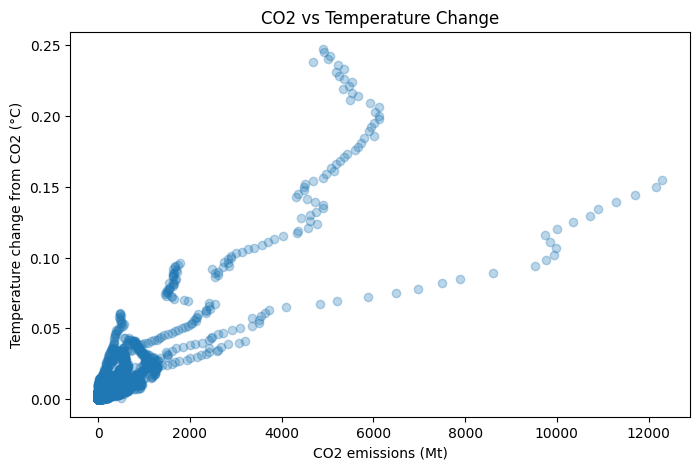

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df_clean['co2'], df_clean['temperature_change_from_co2'], alpha=0.3)
plt.xlabel('CO2 emissions (Mt)')
plt.ylabel('Temperature change from CO2 (°C)')
plt.title('CO2 vs Temperature Change')
plt.show()

---
## Sección 4: Análisis de Correlación


**Celda 14:** Cálculo de la matriz de correlación de Pearson entre CO2, CO2 per cápita, población y cambio de temperatura.

In [14]:
corr_cols = ['co2', 'co2_per_capita', 'population', 'temperature_change_from_co2']
corr_matrix = df_clean[corr_cols].corr()
print(corr_matrix)

                                  co2  co2_per_capita  population  \
co2                          1.000000        0.054050    0.661671   
co2_per_capita               0.054050        1.000000   -0.016153   
population                   0.661671       -0.016153    1.000000   
temperature_change_from_co2  0.859484        0.051867    0.482265   

                             temperature_change_from_co2  
co2                                             0.859484  
co2_per_capita                                  0.051867  
population                                      0.482265  
temperature_change_from_co2                     1.000000  


**Celda 15:** Visualización de la matriz de correlación como mapa de calor (heatmap).

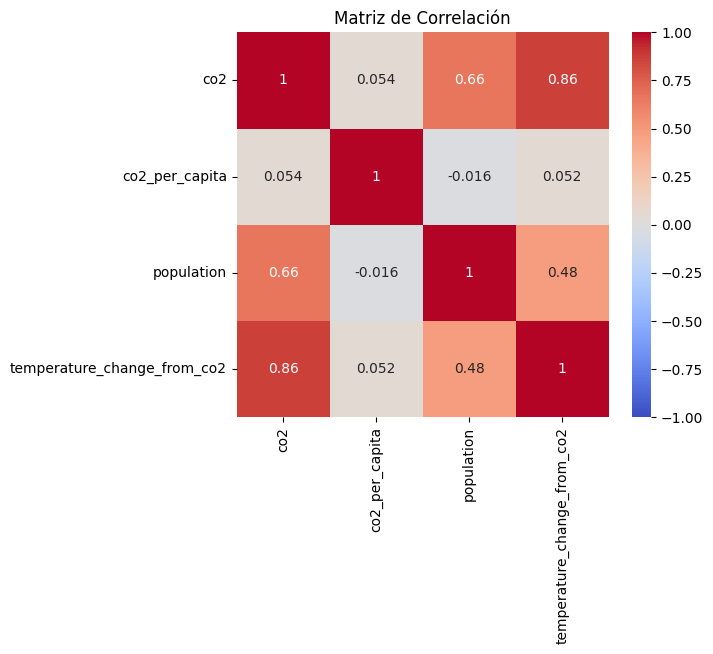

In [15]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.show()

**Celda 16:** Coeficiente de correlación (r) y p-value específicos entre CO2 total y cambio de temperatura, para reportar significancia estadística.

In [16]:
from scipy.stats import pearsonr

r, p = pearsonr(df_clean['co2'], df_clean['temperature_change_from_co2'])
print(f"Coeficiente de correlación (r): {r:.4f}")
print(f"P-value: {p:.6f}")

Coeficiente de correlación (r): 0.8595
P-value: 0.000000


---
## Sección 5: Regresión Lineal


**Celda 17:** División del dataset en conjunto de entrenamiento (80%) y prueba (20%) para el modelo de regresión.

In [17]:
from sklearn.model_selection import train_test_split

X = df_clean[['co2']]
y = df_clean['temperature_change_from_co2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(12174, 1) (3044, 1)


**Celda 18:** Entrenamiento del modelo de regresión lineal simple (CO2 - cambio de temperatura).

In [18]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Coeficiente (pendiente):", modelo.coef_[0])
print("Intercepto:", modelo.intercept_)

Coeficiente (pendiente): 2.3207655717863992e-05
Intercepto: 0.0008771453465616194


**Celda 19:** Evaluación del modelo sobre el conjunto de prueba, usando R² y RMSE como métricas de desempeño.

In [19]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = modelo.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

R²: 0.7245461762668846
RMSE: 0.0072804750409515805


**Celda 20:** Gráfica del ajuste del modelo: datos reales de prueba vs. la línea de predicción.

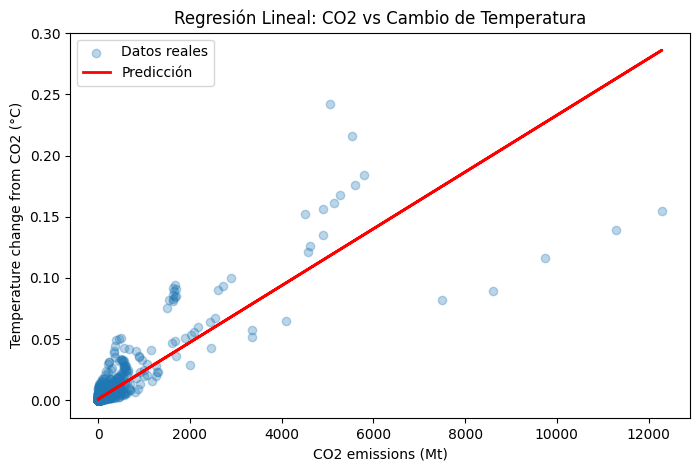

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, alpha=0.3, label='Datos reales')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicción')
plt.xlabel('CO2 emissions (Mt)')
plt.ylabel('Temperature change from CO2 (°C)')
plt.title('Regresión Lineal: CO2 vs Cambio de Temperatura')
plt.legend()
plt.show()

---
## Sección 6: Clustering (K-Means)


**Celda 21:** Selección de variables para el clustering y estandarización con `StandardScaler` (necesario porque CO2, CO2 per cápita y población tienen escalas muy distintas).

In [21]:
from sklearn.preprocessing import StandardScaler

cluster_cols = ['co2', 'co2_per_capita', 'population']
X_cluster = df_clean[cluster_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

**Celda 22:** Método del codo: se prueba K-Means con distintos números de clusters (k = 1 a 9) para elegir el valor óptimo según la inercia.

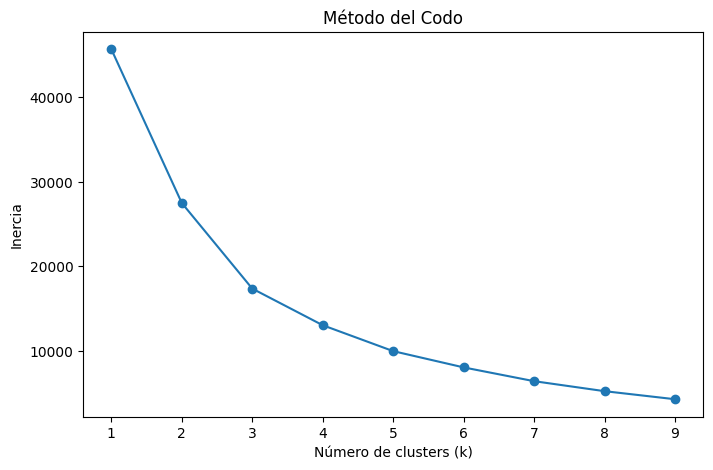

In [22]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(1, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

**Celda 23:** Aplicación de K-Means con k=4 (valor elegido según el método del codo) y asignación del número de cluster a cada fila del dataset.

In [23]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean = df_clean.copy()
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

df_clean['cluster'].value_counts()

cluster
0    15006
3      111
1       81
2       20
Name: count, dtype: int64

**Celda 24:** Promedio de cada variable por cluster (permite interpretar y "ponerle nombre" a cada grupo identificado).

In [24]:
df_clean.groupby('cluster')[cluster_cols + ['temperature_change_from_co2']].mean()

,co2,co2_per_capita,population,temperature_change_from_co2
cluster,,,,
0,61.867426,4.738430,1.558636e+07,0.002286
1,6173.123444,15.833543,5.568830e+08,0.157469
2,25.703250,418.828700,7.046730e+04,0.000050
3,1336.619865,1.217387,9.550744e+08,0.026261


**Celda 25:** Visualización de los 4 clusters sobre la gráfica de CO2 vs cambio de temperatura, coloreados por grupo.

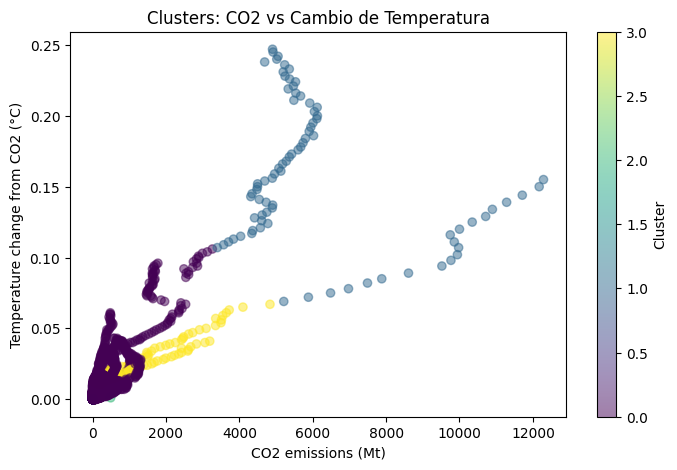

In [25]:
plt.figure(figsize=(8,5))
scatter = plt.scatter(df_clean['co2'], df_clean['temperature_change_from_co2'],
                       c=df_clean['cluster'], cmap='viridis', alpha=0.5)
plt.xlabel('CO2 emissions (Mt)')
plt.ylabel('Temperature change from CO2 (°C)')
plt.title('Clusters: CO2 vs Cambio de Temperatura')
plt.colorbar(scatter, label='Cluster')
plt.show()

---
## Sección 7: Investigación de Casos Atípicos (Cluster 2)


**Celda 26:** Identificación de los países dentro del Cluster 2 (el de CO2 per cápita extremo), ordenados de mayor a menor per cápita.

In [26]:
df_clean[df_clean['cluster'] == 2][['country', 'year', 'co2_per_capita', 'population']].sort_values('co2_per_capita', ascending=False).head(10)

,country,year,co2_per_capita,population
41468,Sint Maarten (Dutch part),1954,782.743,1859.0
41470,Sint Maarten (Dutch part),1956,741.272,2100.0
41465,Sint Maarten (Dutch part),1951,682.203,1578.0
41469,Sint Maarten (Dutch part),1955,610.668,1971.0
41471,Sint Maarten (Dutch part),1957,475.291,2237.0
41473,Sint Maarten (Dutch part),1959,471.248,2544.0
41464,Sint Maarten (Dutch part),1950,463.708,1472.0
41467,Sint Maarten (Dutch part),1953,408.740,1760.0
41472,Sint Maarten (Dutch part),1958,390.174,2387.0
41474,Sint Maarten (Dutch part),1960,376.498,2738.0


**Celda 27:** Estadísticas de población dentro del Cluster 2, para detectar si todos los casos son territorios pequeños o hay excepciones.

In [27]:
df_clean[df_clean['cluster'] == 2]['population'].describe()

count    2.000000e+01
mean     7.046730e+04
std      3.015045e+05
min      1.472000e+03
25%      1.943000e+03
50%      2.641000e+03
75%      4.034750e+03
max      1.351403e+06
Name: population, dtype: float64

**Celda 28:** Mismo cluster, ahora ordenado por población de mayor a menor — esto revela el caso de Kuwait 1991 (incendios petroleros de la Guerra del Golfo), distinto a los demás casos (territorios pequeños como Sint Maarten).

In [28]:
df_clean[df_clean['cluster'] == 2][['country', 'year', 'co2_per_capita', 'population']].sort_values('population', ascending=False).head(10)

,country,year,co2_per_capita,population
24832,Kuwait,1991,364.791,1351403.0
41484,Sint Maarten (Dutch part),1970,240.455,6437.0
41483,Sint Maarten (Dutch part),1969,231.809,5970.0
41481,Sint Maarten (Dutch part),1967,223.414,5090.0
41479,Sint Maarten (Dutch part),1965,229.376,4304.0
41478,Sint Maarten (Dutch part),1964,278.928,3945.0
41477,Sint Maarten (Dutch part),1963,313.931,3605.0
41476,Sint Maarten (Dutch part),1962,359.877,3283.0
41475,Sint Maarten (Dutch part),1961,359.691,2991.0
41474,Sint Maarten (Dutch part),1960,376.498,2738.0


---
## Conclusión

- **Correlación:** r = 0.86 entre CO2 total y cambio de temperatura (fuerte y significativa).
- **Regresión lineal:** R² = 0.72 — el CO2 explica el 72% de la variación del cambio de temperatura.
- **Clustering:** 4 grupos de países identificados, incluyendo un cluster atípico que mezcla
  territorios muy pequeños (Sint Maarten) con un evento histórico extraordinario (Kuwait 1991).

Ver el reporte final y la guía explicativa para la interpretación completa de resultados.
